# Part2 EDA

In [1]:
import os
os.chdir('./proj1_data/')
os.getcwd()

'/home/tako/Kasetsart/statistics/project1/proj1_data'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Data

In [3]:
Dataset_C = "worldbank_2017_2021.csv"
Dataset_B = "countries_regions.xlsx"

In [4]:
orig_dfC = pd.read_csv(Dataset_C)
orig_dfC.head()

,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)"
0,Afghanistan,2017,5.99,58.12,26.42,11.80,2091.4,99.21,20.45,99.84,...,7.230000e+08,7.065000e+09,41.53,62.58,12.20,NaN,NaN,NaN,NaN,NaN
1,Albania,2017,14.56,42.86,19.02,22.34,4813.0,105.84,99.81,103.88,...,2.292000e+09,5.271000e+09,58.09,29.97,17.04,NaN,NaN,NaN,NaN,NaN
2,Algeria,2017,3.16,17.36,11.03,3.14,990.3,104.40,20.84,102.87,...,3.519100e+10,4.605900e+10,42.79,2.33,1.70,NaN,NaN,NaN,NaN,NaN
3,American Samoa,2017,NaN,13.90,NaN,4.65,NaN,NaN,41.67,NaN,...,3.970000e+08,5.950000e+08,162.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Andorra,2017,NaN,40.04,0.56,1.74,NaN,NaN,NaN,NaN,...,1.180000e+08,1.478000e+09,53.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
orig_dfB = pd.read_excel(Dataset_B)
orig_dfB.rename(columns={'CountryName': 'Country Name'}, inplace=True)
orig_dfB.head()

,Country Name,Region,ThirdWorld
0,Afghanistan,South Asia,Yes
1,Albania,Eastern Europe,No
2,Algeria,Africa,No
3,American Samoa,Australia and Oceanea,No
4,Andorra,Western Europe,No


In [6]:
orig_dfm = pd.merge(orig_dfC, orig_dfB, on='Country Name', how='left')
orig_dfm.head()

,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",Region,ThirdWorld
0,Afghanistan,2017,5.99,58.12,26.42,11.80,2091.4,99.21,20.45,99.84,...,41.53,62.58,12.20,NaN,NaN,NaN,NaN,NaN,South Asia,Yes
1,Albania,2017,14.56,42.86,19.02,22.34,4813.0,105.84,99.81,103.88,...,58.09,29.97,17.04,NaN,NaN,NaN,NaN,NaN,Eastern Europe,No
2,Algeria,2017,3.16,17.36,11.03,3.14,990.3,104.40,20.84,102.87,...,42.79,2.33,1.70,NaN,NaN,NaN,NaN,NaN,Africa,No
3,American Samoa,2017,NaN,13.90,NaN,4.65,NaN,NaN,41.67,NaN,...,162.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Australia and Oceanea,No
4,Andorra,2017,NaN,40.04,0.56,1.74,NaN,NaN,NaN,NaN,...,53.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Western Europe,No


In [7]:
orig_dfm.shape

(1080, 197)

In [8]:
orig_dfm.dtypes

Country Name                                                                                                                                    object
Year                                                                                                                                             int64
Agricultural irrigated land (% of total agricultural land)                                                                                     float64
Agricultural land (% of land area)                                                                                                             float64
Agriculture, forestry, and fishing, value added (% of GDP)                                                                                     float64
                                                                                                                                                ...   
Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)          

## Clean

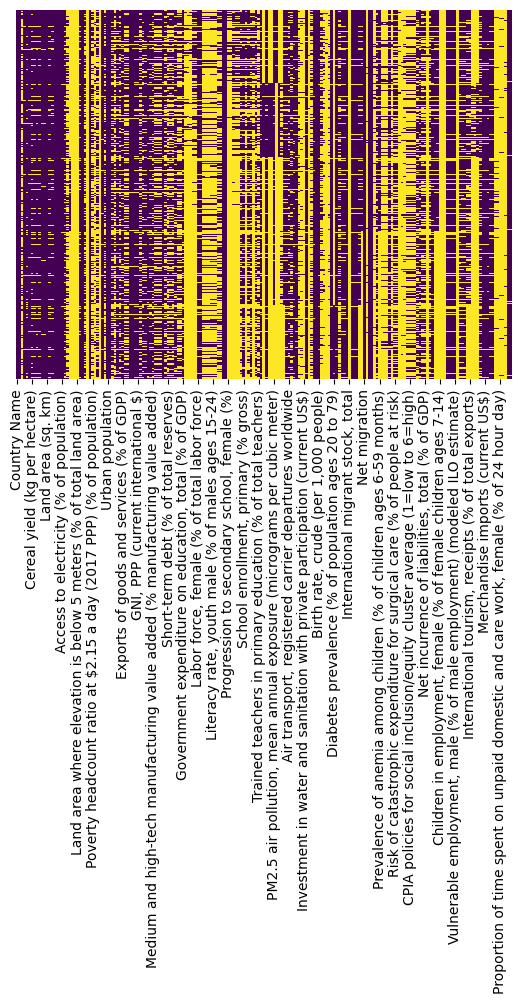

In [9]:
df=orig_dfm.copy()
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.show()

In [10]:
null_percent = df.isnull().sum()/len(df)*100
null_percent

Country Name                                                                                                                                    0.000000
Year                                                                                                                                            0.000000
Agricultural irrigated land (% of total agricultural land)                                                                                     76.851852
Agricultural land (% of land area)                                                                                                              3.240741
Agriculture, forestry, and fishing, value added (% of GDP)                                                                                     10.092593
                                                                                                                                                 ...    
Proportion of time spent on unpaid domestic and care work, female (% of 24 hour da

(1080, 83)


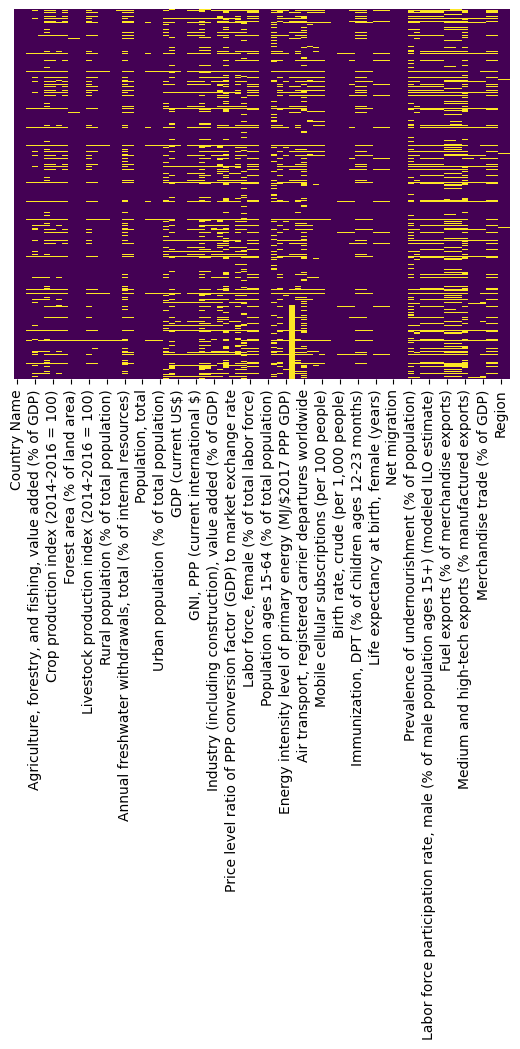

In [11]:
# drop column if missing value > 30%
df_dn = df.dropna(axis=1, thresh=int((0.7) * len(df))).copy()
print(df_dn.shape)
sns.heatmap(df_dn.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.show()

In [12]:
df_dn.columns

Index(['Country Name', 'Year', 'Agricultural land (% of land area)',
       'Agriculture, forestry, and fishing, value added (% of GDP)',
       'Arable land (% of land area)', 'Cereal yield (kg per hectare)',
       'Crop production index (2014-2016 = 100)',
       'Fertilizer consumption (kilograms per hectare of arable land)',
       'Food production index (2014-2016 = 100)',
       'Forest area (% of land area)', 'Forest area (sq. km)',
       'Land area (sq. km)', 'Livestock production index (2014-2016 = 100)',
       'Permanent cropland (% of land area)', 'Rural population',
       'Rural population (% of total population)', 'Surface area (sq. km)',
       'Access to electricity (% of population)',
       'Annual freshwater withdrawals, total (% of internal resources)',
       'Mortality rate, under-5 (per 1,000 live births)',
       'Population growth (annual %)', 'Population, total',
       'Renewable energy consumption (% of total final energy consumption)',
       'Urban popu

In [13]:
for column in df_dn.columns:
    print("=============", column, "=============")
    print(df_dn[column].unique())

============= Country Name =============
['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas, The' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cambodia' 'Cameroon' 'Canada' 'Cayman Islands' 'Chad' 'Channel Islands'
 'Chile' 'China' 'Colombia' 'Comoros' 'Congo, Dem. Rep.' 'Congo, Rep.'
 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus'
 'Czechia' 'Denmark' 'Djibouti' 'Dominica' 'Dominican Republic' 'Ecuador'
 'Egypt, Arab Rep.' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Eswatini' 'Ethiopia' 'Faroe Islands' 'Fiji' 'Finland' 'France'
 'French Polynesia' 'Gabon' 'Gambia, The' 'Georgia' 'Germany' 'Ghana'
 'Gibraltar' 'Greece' 'Greenland' 'Grenada' 'Gua

In [14]:
len(df_dn['Country Name']), len(df_dn['Country Name'].unique())

(1080, 216)

### Notes

#### Dataset C
- Country Name: categorical data which null percent = 0

After scaning all the columns unique, there is no special character except for nan.
- Others: numerical data -> fills with mean/median with respect to skewness.

Clustering
- countries based on GNI per capita, PPP (current international $)

#### Dataset B  
Fills the categorical data with mode
- Region
- ThirdWorld

In [15]:
goal = 'GNI per capita, PPP (current international $)'
len(df_dn[goal]), len(df_dn[goal].unique())

(1080, 855)

In [16]:
print(df_dn[goal].isnull().sum())
df_dn[goal].unique()

104


array([  2360.,  12800.,  13520.,     nan,   6570.,  20160.,  22910.,
        13050.,  36560.,  47090.,  53670.,  13770.,  31510.,  46540.,
         5060.,  15550.,  17720.,  50900.,   8580.,   2960.,  88780.,
        10690.,   8190.,  13470.,  13560.,  14030.,  65700.,  20980.,
         1970.,    790.,   6980.,   3670.,   3660.,  47700.,  46240.,
         1610.,  23590.,  14730.,  14090.,   3340.,   1010.,   3890.,
        19110.,   4900.,  27300.,  24040.,  37240.,  36630.,  56570.,
         4730.,  11510.,  16270.,  11570.,  11120.,   8400.,  14620.,
        32990.,   7950.,   2020.,  58250.,  11800.,  47590.,  45580.,
        13970.,  13060.,  54340.,   4880.,  28460.,  12820.,   9640.,
         2710.,   2100.,  12300.,   5260.,  61840.,  28300.,  55910.,
         6100.,  10460.,  15180.,  10040.,  62200.,  39140.,  41810.,
         9570.,  42980.,   9240.,  22090.,   4120.,   4520.,  41120.,
        54200.,   4800.,   6780.,  28600.,  21060.,   1530.,  19410.,
        32540.,  823

In [17]:
# Fills numerical data

skew_limit = 0.5

numeric_cols = df_dn.select_dtypes(include=['number']).columns

for col in numeric_cols:
    skewness = df_dn[col].skew()

    if abs(skewness) > skew_limit:
        fill_val = df_dn[col].median()
        df_dn[col] = df_dn[col].fillna(fill_val)
    else:
        fill_val = df_dn[col].mean()
        df_dn[col] = df_dn[col].fillna(fill_val)

In [18]:
categorical_cols = df_dn.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if not df_dn[col].mode().empty:
        mode_value = df_dn[col].mode()[0]
        df_dn[col] = df_dn[col].fillna(mode_value)

In [19]:
total_nans = df_dn.isnull().sum().sum()

print(f"Total missing values: {total_nans}")

Total missing values: 0


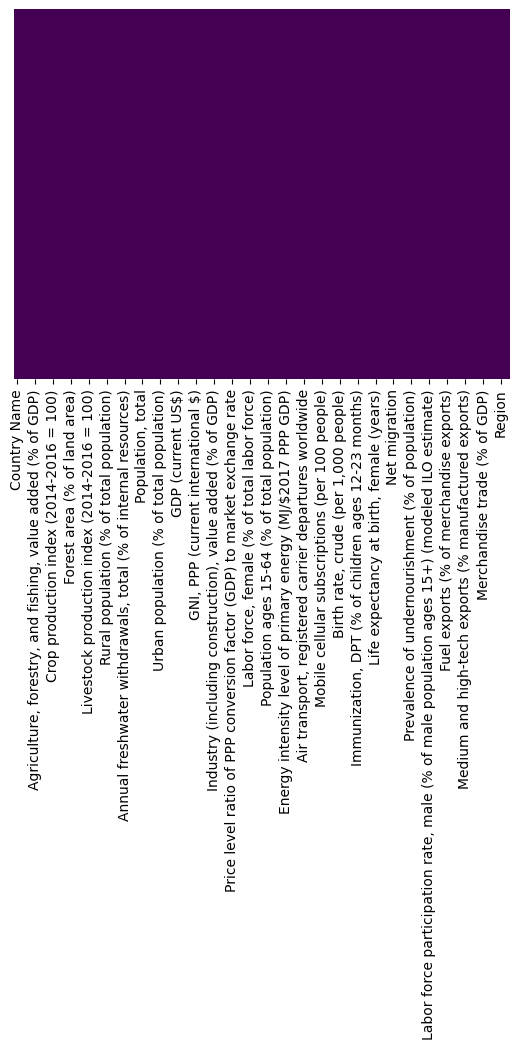

In [20]:
sns.heatmap(df_dn.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.show()

In [21]:
# save to csv

df_dn.to_csv('part2_cleaned.csv', index=False)